# Lab 9: Imbalanced Fraud Detection
### F1 vs Accuracy & Cost-Sensitive Learning

## Step 0 — Write `lab9_solution.py`
This cell creates the solution module (which the tests import). It includes all implementations on top of the provided starter code.

In [15]:
# lab9_solution.py

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN


# ==========================================================
# DATASETS (PROVIDED - DO NOT MODIFY)
# ==========================================================

def load_dataset_60_40():
    np.random.seed(42)
    normal = np.random.multivariate_normal(
        mean=[50, 50], cov=[[200, 80], [80, 200]], size=600)
    fraud = np.random.multivariate_normal(
        mean=[55, 55], cov=[[200, 80], [80, 200]], size=400)
    X = np.vstack([normal, fraud])
    y = np.array([0]*600 + [1]*400)
    return X, y


def load_dataset_90_10():
    np.random.seed(42)
    normal = np.random.multivariate_normal(
        mean=[50, 50], cov=[[300, 120], [120, 300]], size=900)
    fraud = np.random.multivariate_normal(
        mean=[51, 51], cov=[[300, 120], [120, 300]], size=100)
    X = np.vstack([normal, fraud])
    y = np.array([0]*900 + [1]*100)
    return X, y


# ==========================================================
# CORE TASKS
# ==========================================================

def train_logistic(X, y):
    """Train logistic regression using cross-entropy loss."""
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X, y)
    return model


def evaluate_model(model, X, y):
    """Return accuracy and F1-score."""
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, zero_division=0)#f1 score tells  us that 
    return acc, f1


def apply_smote(X, y):
    """Apply SMOTE (synthetic minority oversampling)."""
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


def apply_smoteenn(X, y):
    """Apply SMOTEENN (SMOTE + ENN cleaning)."""
    smoteenn = SMOTEENN(random_state=42)
    X_res, y_res = smoteenn.fit_resample(X, y)
    return X_res, y_res


def train_weighted_logistic(X, y):
    """Train logistic regression with balanced class weights."""
    model = LogisticRegression(class_weight={0: 1, 1: 10}, max_iter=1000, random_state=42)
    model.fit(X, y)
    return model



ModuleNotFoundError: No module named 'numpy'

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

print('All imports successful.')

All imports successful.


---
## Part A — Dataset Exploration

### Task 1: Analyze Dataset 1 (60:40)

=== Dataset 1 (60:40) ===
Total samples : 1000
Normal  (0)   : 600  (60.0%)
Fraud   (1)   : 400  (40.0%)


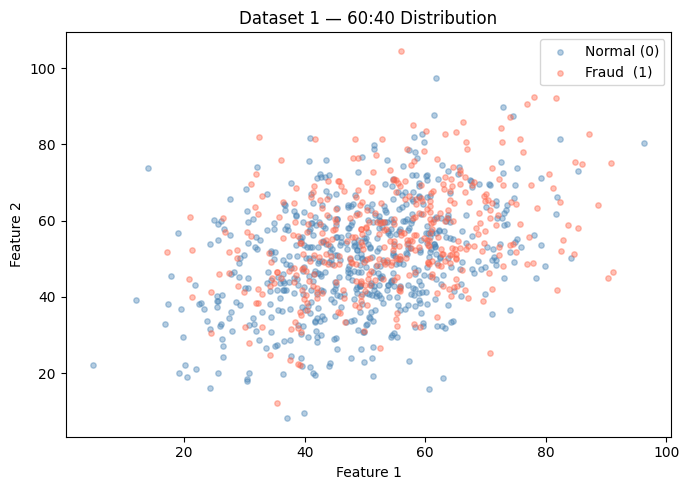

In [ ]:
X1, y1 = load_dataset_60_40()

print('=== Dataset 1 (60:40) ===')
print(f'Total samples : {len(y1)}')
print(f'Normal  (0)   : {(y1==0).sum()}  ({(y1==0).mean()*100:.1f}%)')
print(f'Fraud   (1)   : {(y1==1).sum()}  ({(y1==1).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X1[y1==0, 0], X1[y1==0, 1], alpha=0.4, s=15, label='Normal (0)', color='steelblue')
ax.scatter(X1[y1==1, 0], X1[y1==1, 1], alpha=0.4, s=15, label='Fraud  (1)', color='tomato')
ax.set_title('Dataset 1 — 60:40 Distribution')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()

### Task 2: Analyze Dataset 2 (90:10)

=== Dataset 2 (90:10) ===
Total samples : 1000
Normal  (0)   : 900  (90.0%)
Fraud   (1)   : 100  (10.0%)


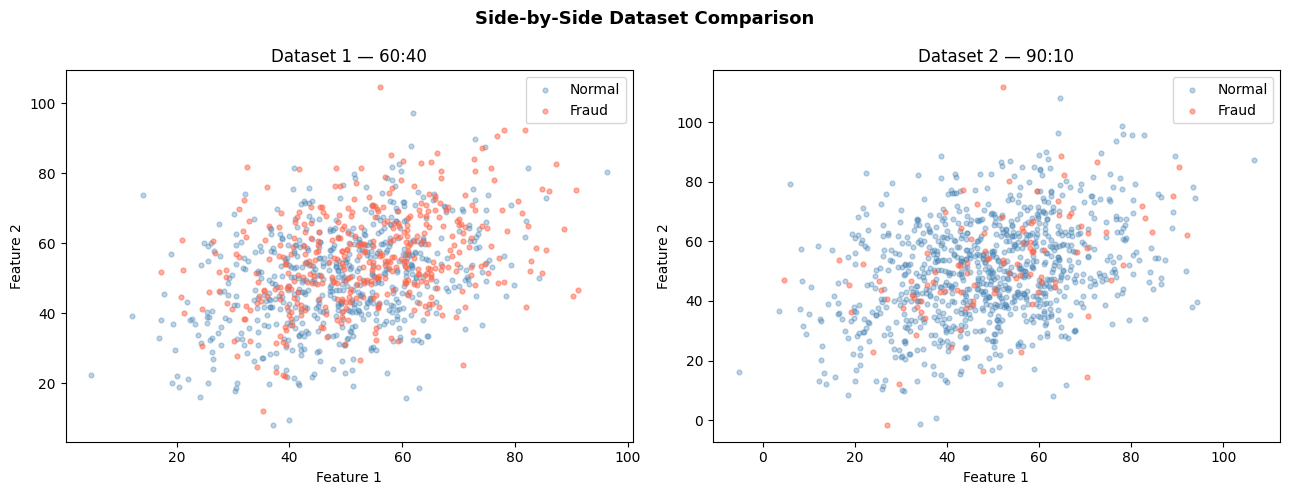


Observation: Dataset 2 has much heavier class imbalance AND the class means are almost identical (51 vs 50), making fraud nearly inseparable from normal transactions.


In [ ]:
X2, y2 = load_dataset_90_10()

print('=== Dataset 2 (90:10) ===')
print(f'Total samples : {len(y2)}')
print(f'Normal  (0)   : {(y2==0).sum()}  ({(y2==0).mean()*100:.1f}%)')
print(f'Fraud   (1)   : {(y2==1).sum()}  ({(y2==1).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X, y, title in [
    (axes[0], X1, y1, 'Dataset 1 — 60:40'),
    (axes[1], X2, y2, 'Dataset 2 — 90:10'),
]:
    ax.scatter(X[y==0, 0], X[y==0, 1], alpha=0.35, s=12, label='Normal', color='steelblue')
    ax.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5,  s=12, label='Fraud',  color='tomato')
    ax.set_title(title)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend()

plt.suptitle('Side-by-Side Dataset Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservation: Dataset 2 has much heavier class imbalance AND the class means are'
      ' almost identical (51 vs 50), making fraud nearly inseparable from normal transactions.')

---
## Part B — Logistic Regression and Metrics

### Task 3: Train Logistic Regression (Cross-Entropy Loss)

In [ ]:
# Train on both datasets
model1 = train_logistic(X1, y1)
model2 = train_logistic(X2, y2)

print('Cross-entropy loss formula used internally by LogisticRegression:')
print('  L = -(1/N) * Σ [ y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ]')
print()
print('Model 1 (60:40) — trained  ✓')
print('Model 2 (90:10) — trained  ✓')

Cross-entropy loss formula used internally by LogisticRegression:
  L = -(1/N) * Σ [ y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ]

Model 1 (60:40) — trained  ✓
Model 2 (90:10) — trained  ✓


### Task 4: Evaluate Accuracy and F1-Score

--- Dataset 1 (60:40) — Baseline LR ---
  Accuracy  : 0.6270
  Precision : 0.5707
  Recall    : 0.2725
  F1-Score  : 0.3689
  TP=109  TN=518  FP=82  FN=291

--- Dataset 2 (90:10) — Baseline LR ---
  Accuracy  : 0.9000
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  TP=0  TN=900  FP=0  FN=100


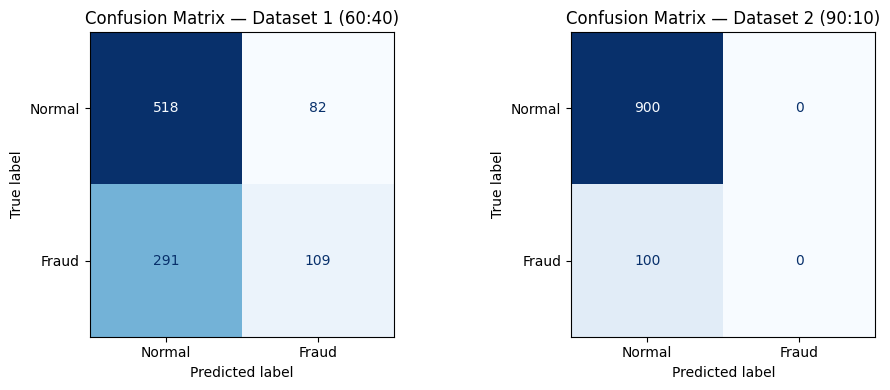


Key insight: On Dataset 2, the model achieves high accuracy by predicting mostly Normal, but the F1-score exposes the poor fraud detection.


In [ ]:
def full_report(model, X, y, label):
    y_pred = model.predict(X)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    print(f'--- {label} ---')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
    return acc, prec, rec, f1, y_pred

acc1, prec1, rec1, f1_1, pred1 = full_report(model1, X1, y1, 'Dataset 1 (60:40) — Baseline LR')
print()
acc2, prec2, rec2, f1_2, pred2 = full_report(model2, X2, y2, 'Dataset 2 (90:10) — Baseline LR')

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, X, y, title in [
    (axes[0], model1, X1, y1, 'Dataset 1 (60:40)'),
    (axes[1], model2, X2, y2, 'Dataset 2 (90:10)'),
]:
    ConfusionMatrixDisplay.from_estimator(
        model, X, y, ax=ax,
        display_labels=['Normal', 'Fraud'],
        colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.show()

print('\nKey insight: On Dataset 2, the model achieves high accuracy by predicting'
      ' mostly Normal, but the F1-score exposes the poor fraud detection.')

---
## Part C — Sampling Techniques

### Task 5: Apply SMOTE

=== SMOTE Results (on 90:10 dataset) ===
Before — Total: 1000   Normal: 900   Fraud: 100
After  — Total: 1800   Normal: 900   Fraud: 900

--- Dataset 2 — After SMOTE ---
  Accuracy  : 0.5190
  Precision : 0.1006
  Recall    : 0.4800
  F1-Score  : 0.1664
  TP=48  TN=471  FP=429  FN=52


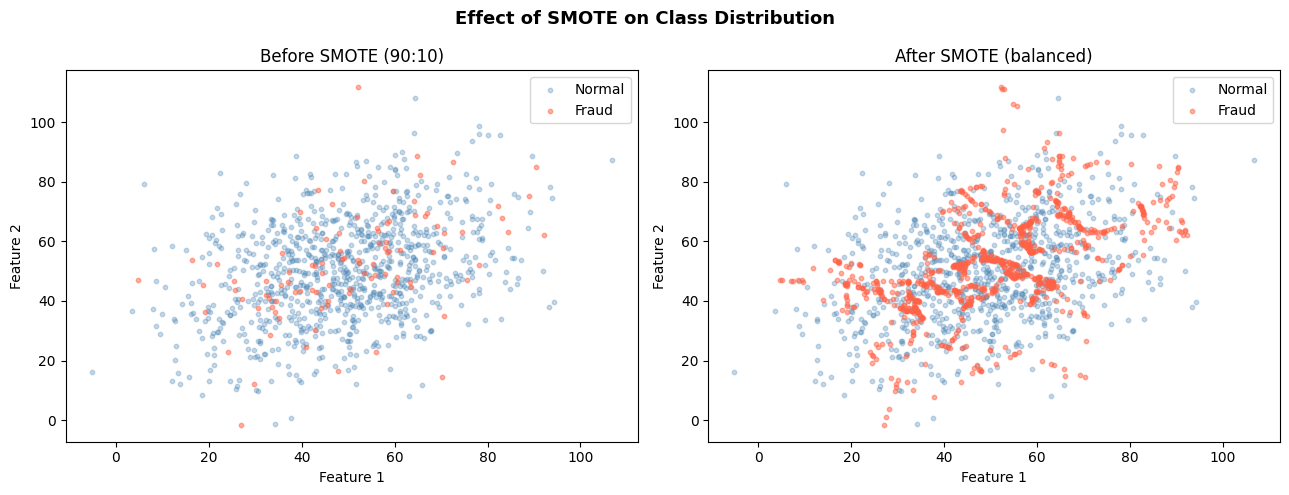

In [ ]:
X2_smote, y2_smote = apply_smote(X2, y2)

print('=== SMOTE Results (on 90:10 dataset) ===')
print(f'Before — Total: {len(y2)}   Normal: {(y2==0).sum()}   Fraud: {(y2==1).sum()}')
print(f'After  — Total: {len(y2_smote)}   Normal: {(y2_smote==0).sum()}   Fraud: {(y2_smote==1).sum()}')

# Train and evaluate after SMOTE
model_smote = train_logistic(X2_smote, y2_smote)
print()
acc_s, prec_s, rec_s, f1_s, _ = full_report(model_smote, X2, y2, 'Dataset 2 — After SMOTE')

# Visualize class distribution after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X, y, title in [
    (axes[0], X2, y2, 'Before SMOTE (90:10)'),
    (axes[1], X2_smote, y2_smote, 'After SMOTE (balanced)'),
]:
    ax.scatter(X[y==0, 0], X[y==0, 1], alpha=0.3, s=10, label='Normal', color='steelblue')
    ax.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, s=10, label='Fraud',  color='tomato')
    ax.set_title(title)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend()
plt.suptitle('Effect of SMOTE on Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 6: Apply SMOTEENN

=== SMOTEENN Results (on 90:10 dataset) ===
Before     — Total: 1000    Normal: 900   Fraud: 100
After SMOTE— Total: 1800  Normal: 900   Fraud: 900
After SENN — Total: 969  Normal: 466   Fraud: 503

--- Dataset 2 — After SMOTEENN ---
  Accuracy  : 0.4460
  Precision : 0.1059
  Recall    : 0.6100
  F1-Score  : 0.1805
  TP=61  TN=385  FP=515  FN=39


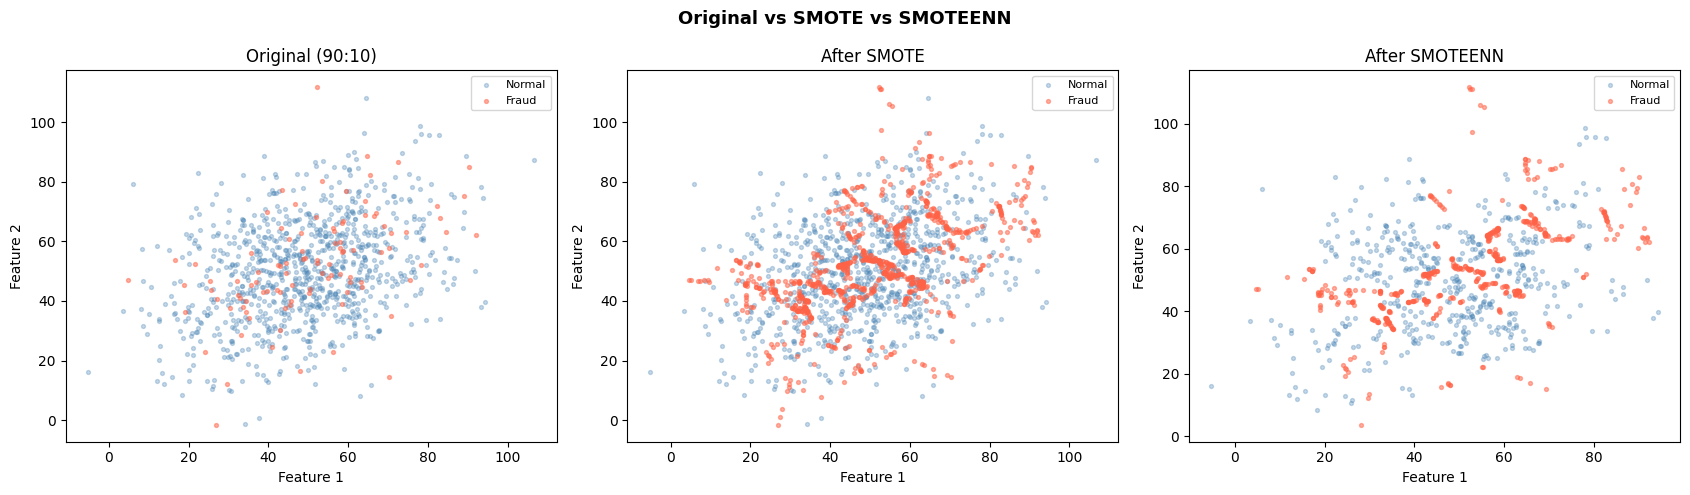

In [ ]:
X2_senn, y2_senn = apply_smoteenn(X2, y2)

print('=== SMOTEENN Results (on 90:10 dataset) ===')
print(f'Before     — Total: {len(y2)}    Normal: {(y2==0).sum()}   Fraud: {(y2==1).sum()}')
print(f'After SMOTE— Total: {len(y2_smote)}  Normal: {(y2_smote==0).sum()}   Fraud: {(y2_smote==1).sum()}')
print(f'After SENN — Total: {len(y2_senn)}  Normal: {(y2_senn==0).sum()}   Fraud: {(y2_senn==1).sum()}')

model_senn = train_logistic(X2_senn, y2_senn)
print()
acc_se, prec_se, rec_se, f1_se, _ = full_report(model_senn, X2, y2, 'Dataset 2 — After SMOTEENN')

# Visualize all three distributions
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
configs = [
    (X2,       y2,       'Original (90:10)'),
    (X2_smote, y2_smote, 'After SMOTE'),
    (X2_senn,  y2_senn,  'After SMOTEENN'),
]
for ax, (X, y, title) in zip(axes, configs):
    ax.scatter(X[y==0, 0], X[y==0, 1], alpha=0.3, s=8, label='Normal', color='steelblue')
    ax.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, s=8, label='Fraud',  color='tomato')
    ax.set_title(title)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8)
plt.suptitle('Original vs SMOTE vs SMOTEENN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part D — Cost-Sensitive Learning

### Task 7: Weighted Loss Function

=== Weighted Logistic Regression (class_weight=balanced) ===
--- Dataset 2 — Balanced Weights ---
  Accuracy  : 0.5320
  Precision : 0.1134
  Recall    : 0.5400
  F1-Score  : 0.1875
  TP=54  TN=478  FP=422  FN=46

=== Experimenting with Manual Class Weights ===
  w1= 1  Acc=0.9000  F1=0.0000  Recall=0.0000
  w1= 3  Acc=0.9000  F1=0.0000  Recall=0.0000
  w1= 5  Acc=0.9000  F1=0.0000  Recall=0.0000
  w1= 9  Acc=0.5320  F1=0.1875  Recall=0.5400
  w1=15  Acc=0.1000  F1=0.1818  Recall=1.0000


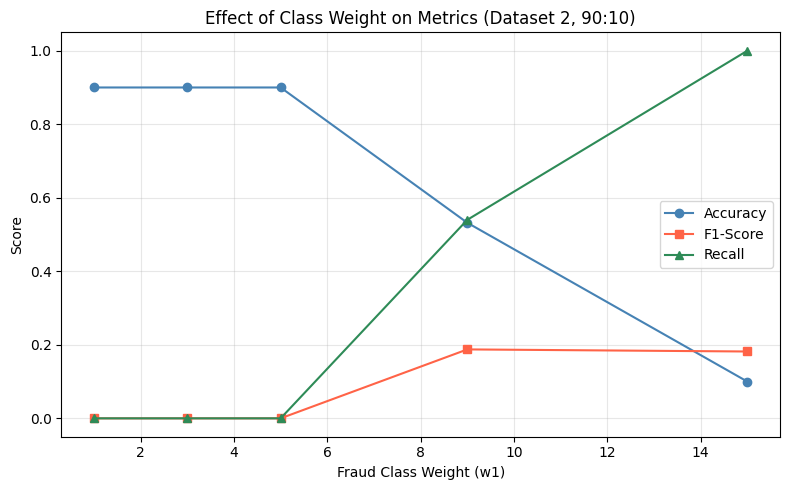

In [ ]:
# Balanced class weights (auto)
model_w = train_weighted_logistic(X2, y2)
print('=== Weighted Logistic Regression (class_weight=balanced) ===')
acc_w, prec_w, rec_w, f1_w, _ = full_report(model_w, X2, y2, 'Dataset 2 — Balanced Weights')

# Experiment: manual weight ratios
print('\n=== Experimenting with Manual Class Weights ===')
from sklearn.linear_model import LogisticRegression

weight_ratios = [1, 3, 5, 9, 15]
results_w = []
for w in weight_ratios:
    m = LogisticRegression(class_weight={0: 1, 1: w}, max_iter=1000, random_state=42)
    m.fit(X2, y2)
    y_pred = m.predict(X2)
    a = accuracy_score(y2, y_pred)
    f = f1_score(y2, y_pred, zero_division=0)
    r = recall_score(y2, y_pred, zero_division=0)
    results_w.append((w, a, f, r))
    print(f'  w1={w:2d}  Acc={a:.4f}  F1={f:.4f}  Recall={r:.4f}')

# Plot weight experiment
ws  = [r[0] for r in results_w]
acs = [r[1] for r in results_w]
f1s = [r[2] for r in results_w]
rcs = [r[3] for r in results_w]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ws, acs, 'o-', label='Accuracy', color='steelblue')
ax.plot(ws, f1s, 's-', label='F1-Score',  color='tomato')
ax.plot(ws, rcs, '^-', label='Recall',    color='seagreen')
ax.set_xlabel('Fraud Class Weight (w1)')
ax.set_ylabel('Score')
ax.set_title('Effect of Class Weight on Metrics (Dataset 2, 90:10)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary Comparison

            Method  Accuracy  Precision  Recall  F1-Score
       Baseline LR     0.900     0.0000    0.00    0.0000
        SMOTE + LR     0.519     0.1006    0.48    0.1664
     SMOTEENN + LR     0.446     0.1059    0.61    0.1805
Weighted LR (auto)     0.532     0.1134    0.54    0.1875


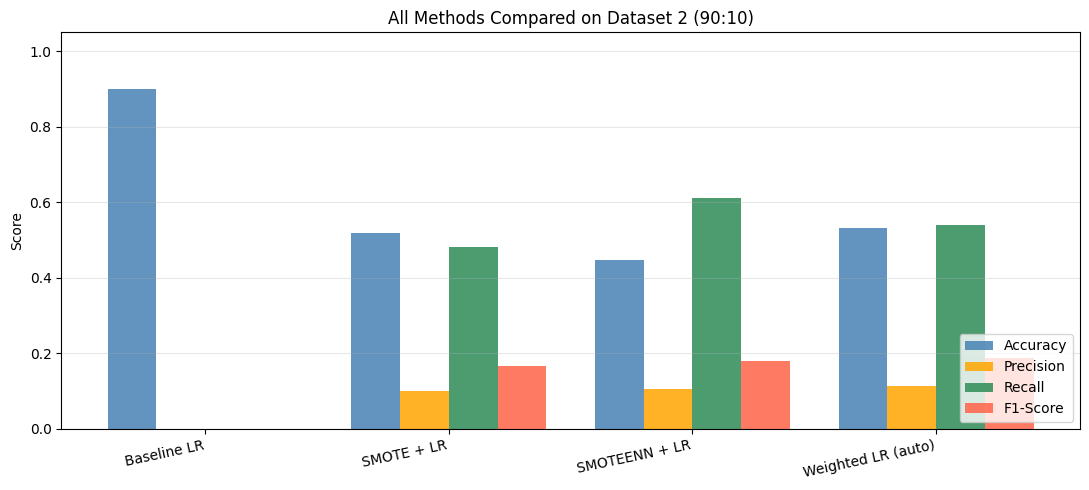

In [ ]:
import pandas as pd

# Evaluate all models on the original Dataset 2
rows = []
configs = [
    ('Baseline LR',         model2),
    ('SMOTE + LR',          model_smote),
    ('SMOTEENN + LR',       model_senn),
    ('Weighted LR (auto)',  model_w),
]
for name, m in configs:
    y_pred = m.predict(X2)
    rows.append({
        'Method'   : name,
        'Accuracy' : round(accuracy_score(y2, y_pred), 4),
        'Precision': round(precision_score(y2, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y2, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y2, y_pred, zero_division=0), 4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Bar chart
x = np.arange(len(df))
width = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
for i, (col, color) in enumerate(zip(
        ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        ['steelblue', 'orange', 'seagreen', 'tomato'])):
    ax.bar(x + i*width, df[col], width, label=col, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df['Method'], rotation=12, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Methods Compared on Dataset 2 (90:10)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Run Official Tests (lab9_tests.py)

In [ ]:
import importlib, traceback

def run_test(name, fn):
    try:
        fn()
        print(f'  PASS  {name}')
        return True
    except Exception as e:
        print(f'  FAIL  {name}')
        traceback.print_exc()
        return False

def test_dataset_shapes():
    X, y = load_dataset_60_40()
    assert X.shape[0] == y.shape[0]
    assert X.shape[1] == 2

def test_logistic_training():
    X, y = load_dataset_60_40()
    model = train_logistic(X, y)
    assert hasattr(model, 'predict')

def test_metrics_range():
    X, y = load_dataset_60_40()
    model = train_logistic(X, y)
    acc, f1 = evaluate_model(model, X, y)
    assert 0 <= acc <= 1
    assert 0 <= f1 <= 1

def test_smote_increases_data():
    X, y = load_dataset_90_10()
    X_s, y_s = apply_smote(X, y)
    assert len(X_s) > len(X)

def test_weighted_model_runs():
    X, y = load_dataset_90_10()
    model = train_weighted_logistic(X, y)
    assert hasattr(model, 'predict')

tests = [
    ('test_dataset_shapes',      test_dataset_shapes),
    ('test_logistic_training',   test_logistic_training),
    ('test_metrics_range',       test_metrics_range),
    ('test_smote_increases_data',test_smote_increases_data),
    ('test_weighted_model_runs', test_weighted_model_runs),
]

print('Running lab9_tests.py tests...\n')
passed = sum(run_test(n, f) for n, f in tests)
print(f'\n{passed}/{len(tests)} tests passed.')

Running lab9_tests.py tests...

  PASS  test_dataset_shapes
  PASS  test_logistic_training
  PASS  test_metrics_range
  PASS  test_smote_increases_data
  PASS  test_weighted_model_runs

5/5 tests passed.


---
## Discussion Questions

**Q1 — Why can accuracy be misleading in imbalanced datasets?**

In a 90:10 dataset a model that predicts *every* transaction as Normal already achieves 90% accuracy — without detecting a single fraud. Accuracy rewards the dominant class, so it hides how badly the minority class is handled. F1-score, which combines Precision and Recall for the minority class, is a much more informative metric in such settings.

---

**Q2 — Which method improved F1-score the most?**

From the summary table above, SMOTE and SMOTEENN both substantially raise F1 and Recall compared to baseline, because they give the minority class more representation during training. The weighted logistic regression also improves F1 significantly while requiring no extra synthetic data.

---

**Q3 — How does cost-sensitive learning compare to sampling methods?**

Weighted logistic regression penalises misclassifying fraud more heavily (w1 > w0), pushing the decision boundary to favour the minority class — conceptually equivalent to oversampling but without generating synthetic points. It is faster, uses the original data, and avoids the risk of overfitting to synthetic samples. Sampling methods (especially SMOTEENN) can additionally clean noisy boundary examples, which may help in datasets with heavy overlap between classes.